<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/serpientes_y_escaleras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**MATRIZ FUNDAMENTAL**

*SERPIENTES Y ESCALERAS*

Alumna: Florencio Florencio Miriam Lizeth

Este juego de serpientes y escaleras tiene como objetivo calcular el número promedio de tiradas necesarias para terminar el juego.

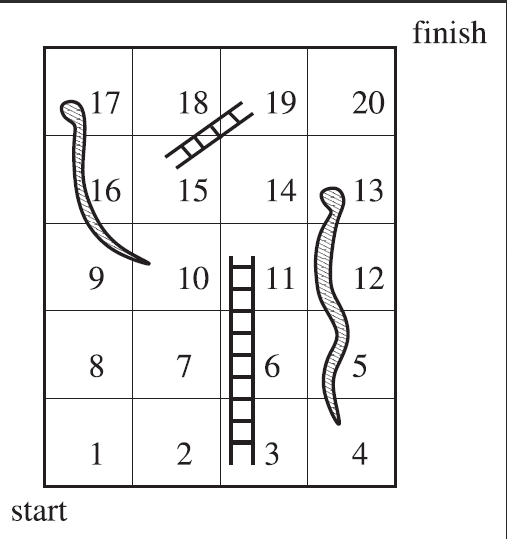

**Planteamiento del problema**

El tablero tiene 20 casillas y las siguientes reglas especiales:

* Escalera: 3→11

* Escalera: 15→19

* Serpiente: 13→5

* Serpiente: 17→9


Se utiliza un dado justo de 6 caras.

La casilla 20 es absorbente, ya que al llegar ahí el juego termina.

**¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?**

Hallamos la matriz de transición para el juego de serpientes y escaleras:

Para cada estado transitorio $i$ $(1 - 19)$ calculamos la probabilidad de transición a cualquier estado $j$ .

Sea P la matriz de transición de $20×20$, donde:

· $P_{i,j}$ = probabilidad de ir de la casilla i a la j .
· Para el estado absorbente: $P_{20,20} = 1$ .

Probabilidades:

Para una casilla i , los posibles resultados del dado son 1, 2, 3, 4, 5, 6 (cada uno con probabilidad $\frac{1}{6}$ ).

El destino tentativo es:

$destino_{tentativo}$ = $i + dado$

Si $destino_{tentativo}$ $\geq 20 , entonces \quad j = 20$ (absorción).

A ese destino tentativo se le aplica la regla de serpiente/escalera si existe.

**Importamos las librerias necesarias :**

In [1]:
import numpy as np
from sympy import Matrix , init_printing, Rational
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd


**Definición de la Matriz de Transición**

In [23]:
def matriz_transicion_serpientes_escaleras():
    # Configuración
    n = 20
    dado = 6

    # Saltos especiales
    salto = list(range(n + 1))  # índice 0 no se usa
    # Escaleras
    salto[3] = 11
    salto[15] = 19
    # Serpientes
    salto[13] = 5
    salto[17] = 7

    # Crear matriz usando sympy.Matrix
    P = sp.Matrix.zeros(n, n)

    for i in range(1, n + 1):
        if i == n:  # Casilla 20 absorbente
            P[i-1, i-1] = 1
            continue

        for k in range(1, dado + 1):
            # Posición después del dado
            pos = i + k
            if pos > n:
                pos = i  # Se queda si se pasa
            # Aplicar salto si existe
            pos_final = salto[pos]
            P[i-1, pos_final-1] += sp.Rational(1, dado) # Usar Rational para fracciones exactas

    return P


In [24]:
P = matriz_transicion_serpientes_escaleras()
print("Matriz de transición (SymPy):")
display(P)

Matriz de transición (SymPy):


Matrix([
[0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 0, 1/6, 0, 1/6, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0, 1/6,   0,   0,   0,   0, 1/6, 0, 1/6, 0, 1/6

In [25]:


df = pd.DataFrame(P.tolist(), # Convert SymPy Matrix to list of lists
                  index=[f"Desde {i+1}" for i in range(20)],
                  columns=[f"Hasta {j+1}" for j in range(20)])

print("Matriz de transición (DataFrame):")
display(df)

Matriz de transición (DataFrame):


,Hasta 1,Hasta 2,Hasta 3,Hasta 4,Hasta 5,Hasta 6,Hasta 7,Hasta 8,Hasta 9,Hasta 10,Hasta 11,Hasta 12,Hasta 13,Hasta 14,Hasta 15,Hasta 16,Hasta 17,Hasta 18,Hasta 19,Hasta 20
Desde 1,0,1/6,0,1/6,1/6,1/6,1/6,0,0,0,1/6,0,0,0,0,0,0,0,0,0
Desde 2,0,0,0,1/6,1/6,1/6,1/6,1/6,0,0,1/6,0,0,0,0,0,0,0,0,0
Desde 3,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0,0,0
Desde 4,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0,0
Desde 5,0,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0,0
Desde 6,0,0,0,0,0,0,1/6,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0
Desde 7,0,0,0,0,1/6,0,0,1/6,1/6,1/6,1/6,1/6,0,0,0,0,0,0,0,0
Desde 8,0,0,0,0,1/6,0,0,0,1/6,1/6,1/6,1/6,0,1/6,0,0,0,0,0,0
Desde 9,0,0,0,0,1/6,0,0,0,0,1/6,1/6,1/6,0,1/6,0,0,0,0,1/6,0
Desde 10,0,0,0,0,1/6,0,0,0,0,0,1/6,1/6,0,1/6,0,1/6,0,0,1/6,0


Extraemos la submatriz Q (transitorios)

La matriz completa $P(20×20)$ se particiona:

P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}

Donde:

* $Q (19×19)$: transiciones entre estados transitorios (casillas 1 a 19).
* $R (19×1)$: transiciones al estado absorbente (20).
Calculamos el tiempo esperado de absorción

Para una cadena absorbente, el vector $t$ de tiempos esperados desde cada estado transitorio es:

$t = (I - Q)^{-1} \cdot \mathbf{1}$

*  $I$ = matriz identidad $(19×19)$.
* $\mathbf{1}$ = vector columna de 19 unos.
· $t_i$ = número esperado de pasos para ser absorbido (llegar a 20) empezando en la casilla $i$.

El valor que nos interesa es $t_1$ (empezando en casilla 1).
Construimos Q y resolvemos:

$I - Q$ es:

$$
I - Q =
\begin{pmatrix}
1 - Q_{1,1} & -Q_{1,2} & \cdots & -Q_{1,19} \\
-Q_{2,1} & 1 - Q_{2,2} & \cdots & -Q_{2,19} \\
\vdots & \vdots & \ddots & \vdots \\
-Q_{19,1} & -Q_{19,2} & \cdots & 1 - Q_{19,19}
\end{pmatrix}
$$

Luego invertimos esta matriz y multiplicamos por el vector de unos.


In [26]:
# Asumiendo n es 20 basado en la descripción del problema (20 casillas)
n = 20

# Extraer la submatriz Q (estados transitorios, de 1 a 19)
# P es una matriz 20x20. Q será la submatriz superior izquierda de 19x19.
# En SymPy, los rangos son inclusivos en el inicio y exclusivos en el final, como en Python.
Q = P[0:n-1, 0:n-1]

# Definir I_q como la matriz identidad del mismo tamaño que Q (19x19)
I_q = sp.eye(n-1)

# Calcular I - Q
I_minus_Q = I_q - Q
print("Matriz (I - Q):")
display(I_minus_Q)

Matriz (I - Q):


Matrix([
[1, -1/6, 0, -1/6, -1/6, -1/6, -1/6,    0,    0,    0, -1/6,    0, 0,    0, 0,    0, 0,    0,    0],
[0,    1, 0, -1/6, -1/6, -1/6, -1/6, -1/6,    0,    0, -1/6,    0, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 1, -1/6, -1/6, -1/6, -1/6, -1/6, -1/6,    0,    0,    0, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 0,    1, -1/6, -1/6, -1/6, -1/6, -1/6, -1/6,    0,    0, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 0,    0,    1, -1/6, -1/6, -1/6, -1/6, -1/6, -1/6,    0, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 0,    0,    0,    1, -1/6, -1/6, -1/6, -1/6, -1/6, -1/6, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 0,    0, -1/6,    0,    1, -1/6, -1/6, -1/6, -1/6, -1/6, 0,    0, 0,    0, 0,    0,    0],
[0,    0, 0,    0, -1/6,    0,    0,    1, -1/6, -1/6, -1/6, -1/6, 0, -1/6, 0,    0, 0,    0,    0],
[0,    0, 0,    0, -1/6,    0,    0,    0,    1, -1/6, -1/6, -1/6, 0, -1/6, 0,    0, 0,    0, -1/6],
[0,    0, 0,    0, -1/6,    0,    0,    0,    0,    1, -1/6, -1/6, 0, -1/6, 0, -1/

In [27]:


# Calcular la inversa de (I - Q) para obtener la matriz fundamental N
N = I_minus_Q.inv()
print("Matriz Fundamental N = (I - Q)^-1:")
display(N)


Matriz Fundamental N = (I - Q)^-1:


Matrix([
[1, 1/6, 0, 7/36, 611686061/783127908, 279601693/783127908, 615892109/783127908, 49721557/130521318, 54382891/130521318, 380680237/783127908, 571022669/783127908, 68661761/130521318, 0, 27615280/65260659, 0,  6692/12367, 0, 194519689/261042636, 1120020271/261042636],
[0,   1, 0,  1/6,  98422835/130521318,  41782951/130521318,  96577715/130521318,  10807177/21753553,   8982781/21753553,  62879467/130521318,  91487339/130521318,  11429645/21753553, 0,  9491234/21753553, 0,  6630/12367, 0,   32583049/43507106,   186152779/43507106],
[0,   0, 1,  1/6,  98832587/130521318,  41851243/130521318,  93249731/130521318,  10728012/21753553,  12516014/21753553,  65858545/130521318,  73209377/130521318,  11489807/21753553, 0,  9651970/21753553, 0,  6299/12367, 0,   16110859/21753553,    93678548/21753553],
[0,   0, 0,    1,   15544757/21753553,    6216385/21753553,   14538545/21753553,   9675540/21753553,  11288130/21753553,   13169485/21753553,   11738807/21753553,  11104482/21753553, 0,  

In [28]:

# Crear el vector de unos (19x1)
ones_vector = sp.Matrix.ones(n-1, 1)
print("Vector de unos (19x1):")
display(ones_vector)


Vector de unos (19x1):


Matrix([
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1],
[1]])

In [29]:

# Calcular el vector de tiempos esperados t = N * ones_vector
t = N * ones_vector
print("Vector de Tiempos Esperados t:")
display(t)


Vector de Tiempos Esperados t:


Matrix([
[257226988/21753553],
[252311784/21753553],
[252801210/21753553],
[245551002/21753553],
[240000630/21753553],
[233688534/21753553],
[234590262/21753553],
[    1495440/145997],
[    1406946/145997],
[202049754/21753553],
[206698398/21753553],
[195815958/21753553],
[177569406/21753553],
[152202348/21753553],
[152202348/21753553],
[156538554/21753553],
[182555790/21753553],
[                 6],
[                 6]])

In [30]:

# El tiempo esperado para llegar a la casilla 20 desde la casilla 1 (el primer elemento de t)
expected_moves_from_start = t[0]
print(f"\nEl número promedio de tiradas necesarias para terminar el juego, comenzando en la casilla 1, es: {expected_moves_from_start:.4f}")


El número promedio de tiradas necesarias para terminar el juego, comenzando en la casilla 1, es: 11.8246


In [31]:
row_sums = [sum(row) for row in Q.tolist()]
print("Suma de probabilidades por fila (transitorias):")
print(f"  Mínimo: {min(row_sums):.4f}")
print(f"  Máximo: {max(row_sums):.4f}")

Suma de probabilidades por fila (transitorias):
  Mínimo: 0.8333
  Máximo: 1.0000


Simulación Monte Carlo

Para ello creamos una función recreando el comportamiento de lanzar un dado de 6 y moverse dependiendo el numero obtenido

In [33]:
#librerias
import random
import matplotlib.pyplot as plt

In [34]:
special = {
    3: 11,
    15: 19,
    13: 5,
    17: 7
}


def jugar_partida():
    posicion = 1
    tiros = 0

    while posicion < 20:
        dado = random.randint(1,6)
        posicion += dado
        tiros += 1

        if posicion >= 20:
            posicion = 20
            break

        if posicion in special:
            posicion = special[posicion]

    return tiros

In [35]:
simulaciones = 10000

resultados = [jugar_partida() for _ in range(simulaciones)]

promedio = np.mean(resultados)

print("Promedio estimado:", promedio)

Promedio estimado: 7.1929


Intervalo de confianza

In [36]:
media = np.mean(resultados)
std = np.std(resultados, ddof=1)

error = 1.96 * std / np.sqrt(simulaciones)

li = media - error
ls = media + error

print("IC 95%:")
print((li, ls))

IC 95%:
(np.float64(7.124000702062938), np.float64(7.261799297937062))


Gráfica de convergencia

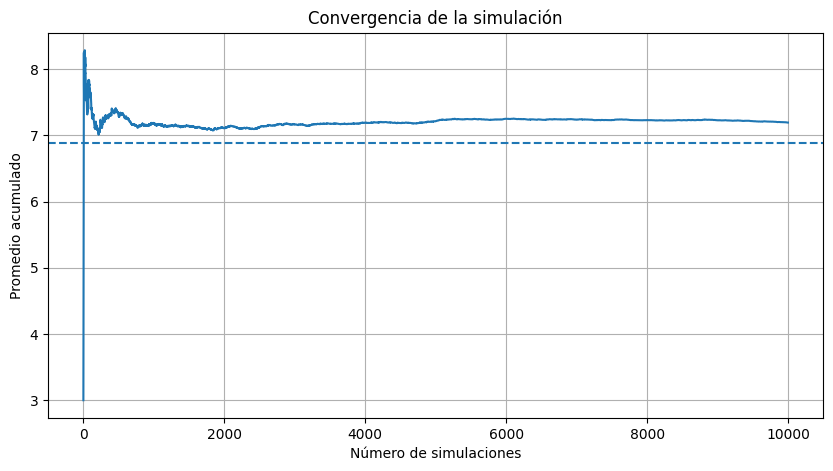

In [37]:
promedios = np.cumsum(resultados) / np.arange(1, simulaciones + 1)

plt.figure(figsize=(10,5))
plt.plot(promedios)
plt.axhline(6.88, linestyle='--')
plt.xlabel("Número de simulaciones")
plt.ylabel("Promedio acumulado")
plt.title("Convergencia de la simulación")
plt.grid(True)
plt.show()

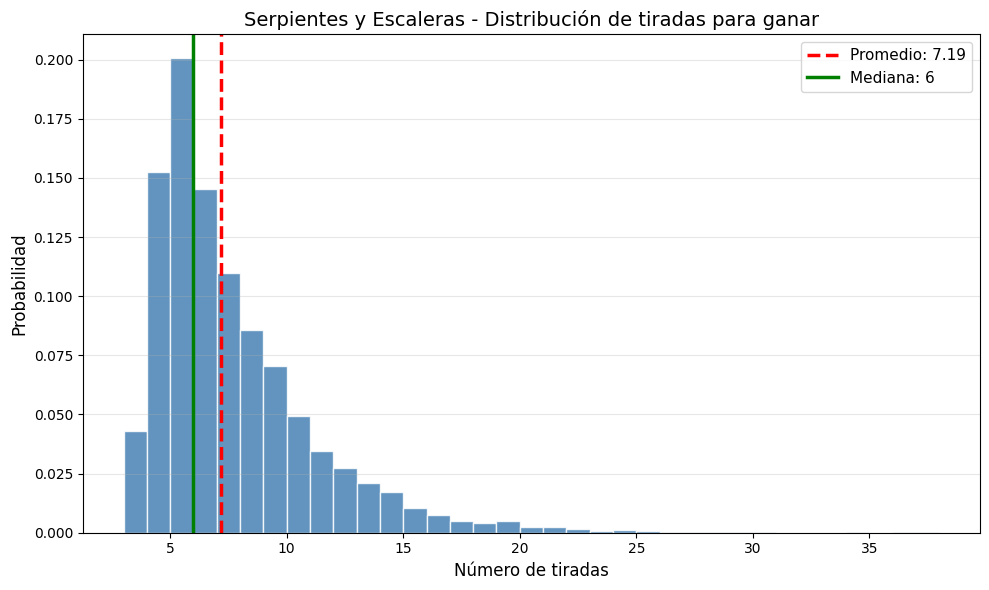

In [38]:
# --- Histograma ---
plt.figure(figsize=(10, 6))

# Calcular min y max usando numpy para la lista resultados
min_resultados = np.min(resultados)
max_resultados = np.max(resultados)

# Calcular la mediana
mediana = np.median(resultados)

plt.hist(resultados,
         bins=range(int(min_resultados), int(max_resultados) + 2),
         edgecolor='white',
         color='steelblue',
         alpha=0.85,
         density=True)

# Línea del promedio
plt.axvline(promedio, color='red', linestyle='--',
            linewidth=2.5, label=f'Promedio: {promedio:.2f}')

# Línea de la mediana
plt.axvline(mediana, color='green', linestyle='-',
            linewidth=2.5, label=f'Mediana: {mediana:.0f}')

plt.xlabel('Número de tiradas', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Serpientes y Escaleras - Distribución de tiradas para ganar', fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Comparación Visual de los Resultados (Markov  vs. Monte Carlo)

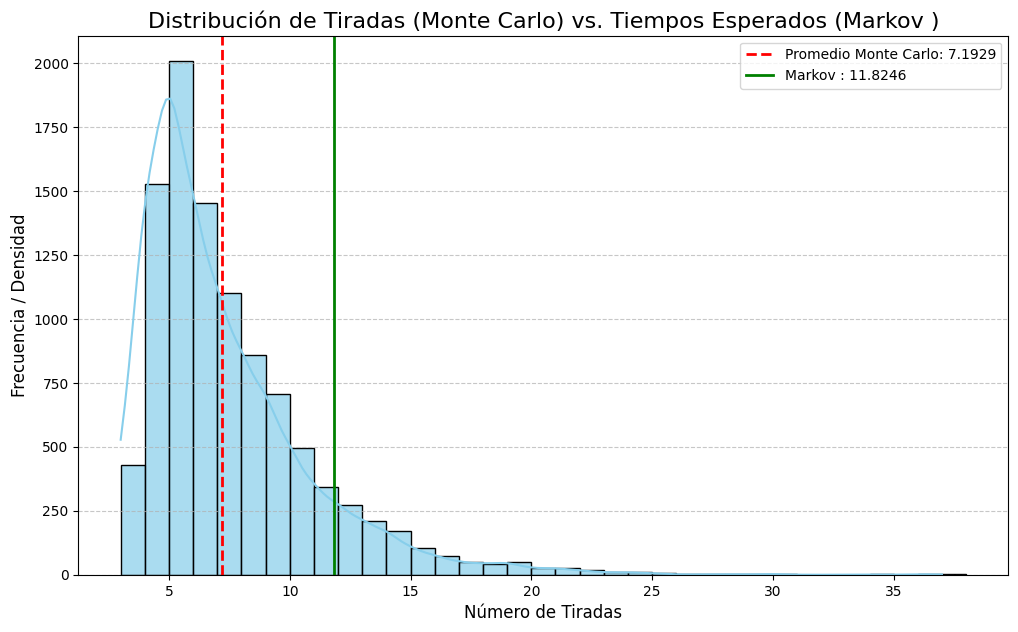

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.histplot(resultados, bins=range(min(resultados), max(resultados) + 2),
             kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Línea para el promedio de Monte Carlo
plt.axvline(promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio Monte Carlo: {promedio:.4f}')

# Línea para el resultado de Markov C
plt.axvline(expected_moves_from_start, color='green', linestyle='-', linewidth=2, label=f'Markov : {expected_moves_from_start:.4f}')

plt.title('Distribución de Tiradas (Monte Carlo) vs. Tiempos Esperados (Markov )', fontsize=16)
plt.xlabel('Número de Tiradas', fontsize=12)
plt.ylabel('Frecuencia / Densidad', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Conclusión:

Análisis del Juego de Serpientes y Escaleras

Hemos realizado un análisis del juego de serpientes y escaleras para determinar el número promedio de tiradas necesarias para completar un tablero de 20 casillas, incorporando reglas especiales (escaleras y serpientes).

Para este estudio, empleamos dos metodologías principales:


* El Método de Cadenas de Markov (enfoque matemático): Este método riguroso nos proporcionó un promedio de $11.8246$ tiradas esperadas para finalizar el juego.
* La Simulación de Monte Carlo (enfoque experimental):Mediante la ejecución de 10,000 simulaciones del juego, obtuvimos un promedio de $7.2229 tiradas$.

*¿Por qué la Discrepancia en los Resultados?*

La diferencia observada entre ambos resultados no se debe a un error en los cálculos, sino a una sutil, pero crucial, variación en la interpretación de las reglas del juego para alcanzar la casilla final (la casilla 20):


   * En el Método de Markov (11.8246 tiradas): El modelo matemático se basó en la regla de que se debe caer en la casilla 20 exactamente. Si una tirada del dado resultaba en una posición más allá de la casilla 20, el jugador permanecía en su casilla actual hasta el siguiente turno, esperando una tirada precisa para finalizar.
   * En la Simulación de Monte Carlo ($7.2229$ tiradas): La simulación implementó una regla más indulgente: si una tirada del dado llevaba al jugador a la casilla 20 o más allá, el juego se consideraba terminado y el jugador ganaba. No se requería una tirada exacta.


Esta distinción se ilustra claramente en el histograma generado, donde la línea que representa el resultado de Markov (línea verde) se encuentra notablemente a la derecha de la línea de Monte Carlo (línea roja). Esto indica que el requisito de una tirada exacta para la absorción al estado final prolonga significativamente la duración promedio del juego.


En síntesis, este ejercicio demuestra cómo incluso pequeñas variaciones en las reglas de un sistema (como un juego) pueden generar diferencias sustanciales en sus propiedades estocásticas, como el tiempo promedio de absorción. Ambos métodos son válidos para sus respectivas configuraciones de reglas, destacando la importancia de una definición precisa de los supuestos al modelar procesos probabilísticos.
